[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/00-setup/00_environment_smoke_test.ipynb)

# Does Your Machine Work?

**Session 1 · run this once before Session 2 · no homework depends on it**

This notebook teaches nothing. It is a receipt: it proves that the environment
on your laptop — or the Colab tab you opened instead — can do what the rest of
the course will ask of it.

Run every cell, top to bottom. If the last cell prints `ENVIRONMENT OK`, you are
done and Session 2 will not surprise you. If anything fails, the failure names
what to fix, and `docs/setup.md` has the fix. **Bring a failure to office hours
rather than to the first lab** — installing during class is the one thing this
course never plans for.

In [1]:
import platform
import sys

print("python  ", sys.version.split()[0], f"({platform.python_implementation()})")
print("platform", platform.system(), platform.machine())
print("executable", sys.executable)

major, minor = sys.version_info[:2]
if (major, minor) < (3, 11):
    print("\nPROBLEM: this course needs Python 3.11 or newer.")
else:
    print("\nPython version is fine.")

python   3.14.6 (CPython)
platform Windows AMD64
executable C:\Users\fairl\Documents\UofI\5771\code\.venv\Scripts\python.exe

Python version is fine.


`sys.executable` is worth a second look. If it points somewhere you did not
expect — a system Python, another project's virtual environment — then the
packages below are being installed somewhere you did not expect either, and that
is the single most common cause of "but I installed it".

In [2]:
import importlib.metadata as md

REQUIRED = {"numpy": "1.26", "pandas": "2.0", "scikit-learn": "1.4",
            "matplotlib": "3.8", "seaborn": "0.13"}

def parts(v):
    out = []
    for piece in v.split(".")[:2]:
        digits = "".join(c for c in piece if c.isdigit())
        out.append(int(digits) if digits else 0)
    return tuple(out)

missing, stale, ok = [], [], []
for name, floor in REQUIRED.items():
    try:
        have = md.version(name)
    except md.PackageNotFoundError:
        missing.append(name)
        continue
    (stale if parts(have) < parts(floor) else ok).append(f"{name} {have}")

for line in ok:
    print("  ok      ", line)
for line in stale:
    print("  too old ", line)
for name in missing:
    print("  MISSING ", name)

  ok       numpy 2.5.2
  ok       pandas 3.0.5
  ok       scikit-learn 1.9.0
  ok       matplotlib 3.11.1
  ok       seaborn 0.13.2


Anything in the `MISSING` or `too old` list is fixed the same way, from the
course requirements file rather than one package at a time:

```
pip install -r requirements.txt
```

On Colab everything above is already present; the versions will differ from a
local install and that is fine.

## The workflow, once, small

Five lines is the whole shape of supervised learning: get data, hold some of it
back, fit, predict, score. Session 1 showed it on slides. Here it runs.

In [3]:
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

print("train rows:", X_train.shape[0], " test rows:", X_test.shape[0])
print("test accuracy:", round(model.score(X_test, y_test), 3))

train rows: 133  test rows: 45
test accuracy: 1.0


The number itself does not matter yet — three wine cultivars are separable and
almost anything scores well. What matters is that it printed at all, and that
the score came from rows the model never saw.

## Can you draw?

Plotting fails in its own ways: a missing backend, a headless machine, a font
cache being rebuilt. Better to find out now.

matplotlib backend: module://matplotlib_inline.backend_inline


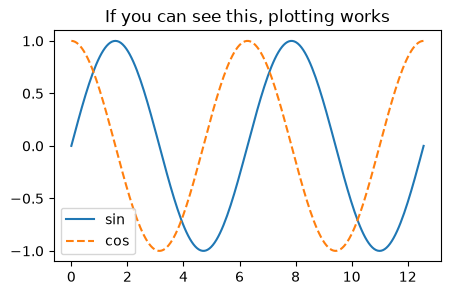

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib backend:", matplotlib.get_backend())

fig, ax = plt.subplots(figsize=(5, 3))
grid = np.linspace(0, 4 * np.pi, 200)
ax.plot(grid, np.sin(grid), label="sin")
ax.plot(grid, np.cos(grid), label="cos", linestyle="--")
ax.set_title("If you can see this, plotting works")
ax.legend()
plt.show()

## Can you read a file?

Every dataset in this course arrives as a file. This writes one, reads it back,
and checks that pandas inferred the types you would want.

In [5]:
import pandas as pd
from pathlib import Path

scratch = Path("smoke_test.csv")
pd.DataFrame({"id": [1, 2, 3],
              "measured_at": ["2026-08-25", "2026-08-27", "2026-09-01"],
              "value": [1.5, 2.5, None]}).to_csv(scratch, index=False)

back = pd.read_csv(scratch, parse_dates=["measured_at"])
print(back.dtypes.to_string())
print("\nmissing values per column:")
print(back.isna().sum().to_string())
scratch.unlink()

id                      int64
measured_at    datetime64[us]
value                 float64

missing values per column:
id             0
measured_at    0
value          1


One `NaN` in `value` is deliberate: it is there so you can see that pandas
reports it rather than hiding it, and that `value` stayed a float column because
of it.

## The receipt

In [6]:
checks = {
    "Python >= 3.11": sys.version_info[:2] >= (3, 11),
    "core packages present": not missing and not stale,
    "fit/predict/score ran": model.score(X_test, y_test) > 0.5,
    "matplotlib drew a figure": fig is not None,
    "pandas read a CSV": len(back) == 3,
}
for name, passed in checks.items():
    print(f"  {'PASS' if passed else 'FAIL'}  {name}")

print()
print("ENVIRONMENT OK" if all(checks.values()) else "ENVIRONMENT NOT READY — see docs/setup.md")

  PASS  Python >= 3.11
  PASS  core packages present
  PASS  fit/predict/score ran
  PASS  matplotlib drew a figure
  PASS  pandas read a CSV

ENVIRONMENT OK


## If something failed

- **Wrong Python, or `sys.executable` in an unexpected place** — the virtual
  environment is not active. `docs/setup.md`, section *Environment Setup*.
- **A missing package** — `pip install -r requirements.txt` inside the activated
  environment. Watch which `pip` runs: `which pip` should sit next to the
  `sys.executable` printed above.
- **Nothing works and you have a deadline** — open this notebook in Colab and
  keep going. Colab is a supported way to take this course; get the local
  install sorted out during office hours rather than the night before HW 1.

## Where to go next

- **`docs/setup.md`** — the full install, including the deeper layers
  (`requirements-pytorch.txt`) you will not need until Session 19.